In [1]:
from pathlib import Path
import os

# If notebook runs from test_notebooks/, move to repo root first.
if Path.cwd().name == 'test_notebooks':
    os.chdir('..')

print('Current working directory:', Path.cwd())

Current working directory: /home/bhchen/LearnKalmanGain


Saved grid image to: save/doubling1d_results/doubling1d_results_grid_step100_with_enkf_and_legend.png


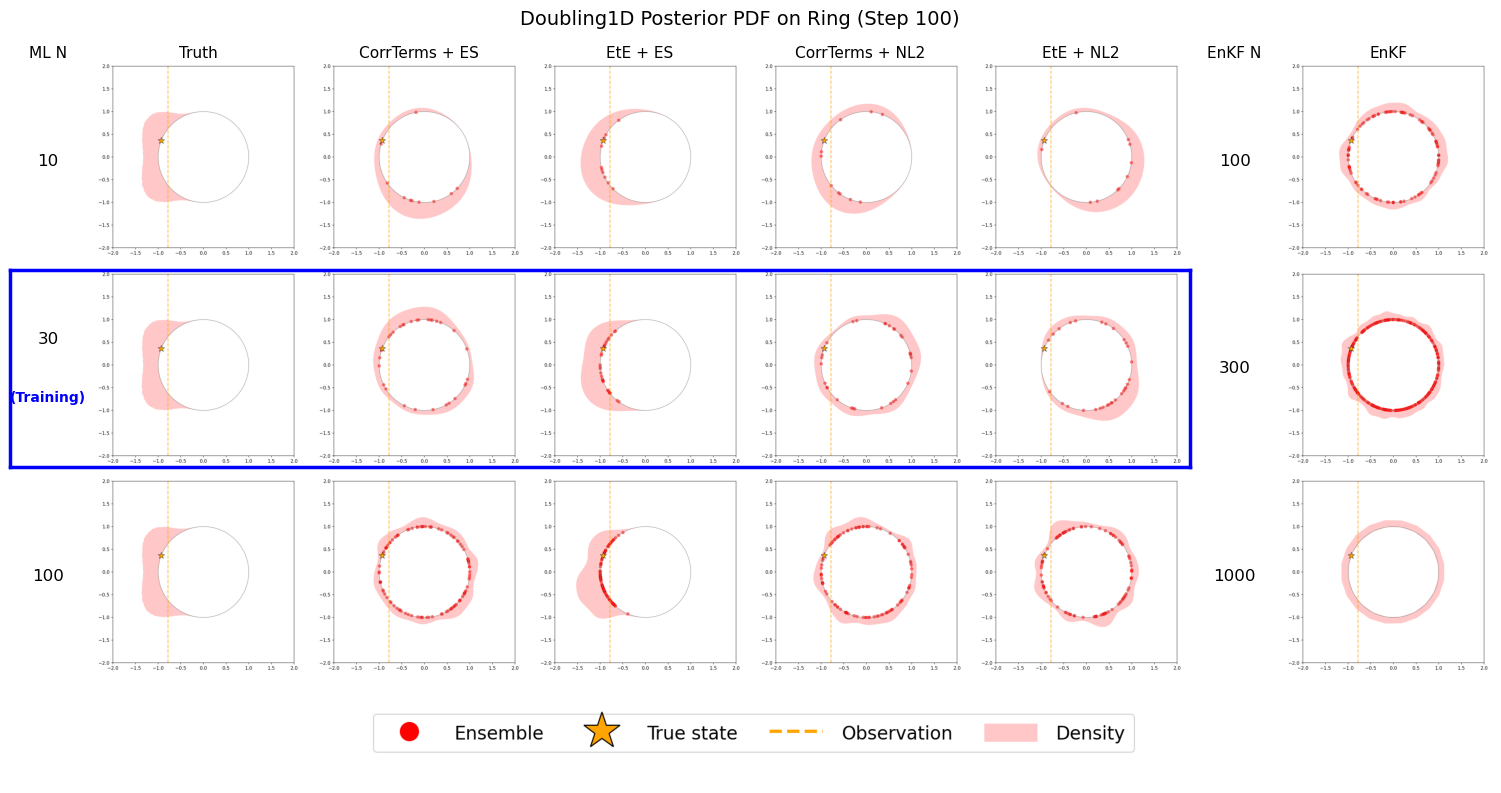

Saved grid image to: save/doubling1d_results/doubling1d_results_grid_step150_with_enkf_and_legend.png


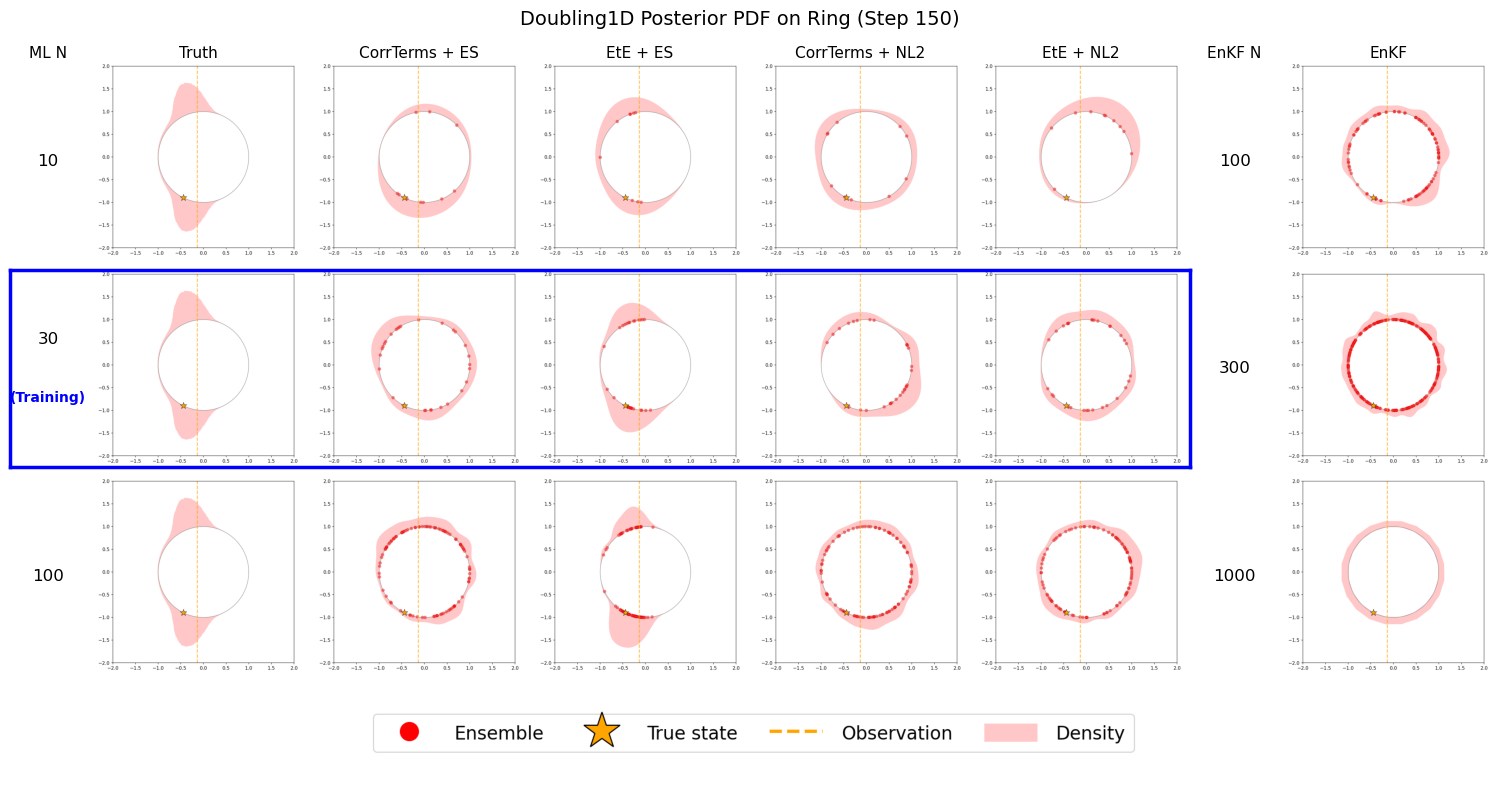

Saved grid image to: save/doubling1d_results/doubling1d_results_grid_step200_with_enkf_and_legend.png


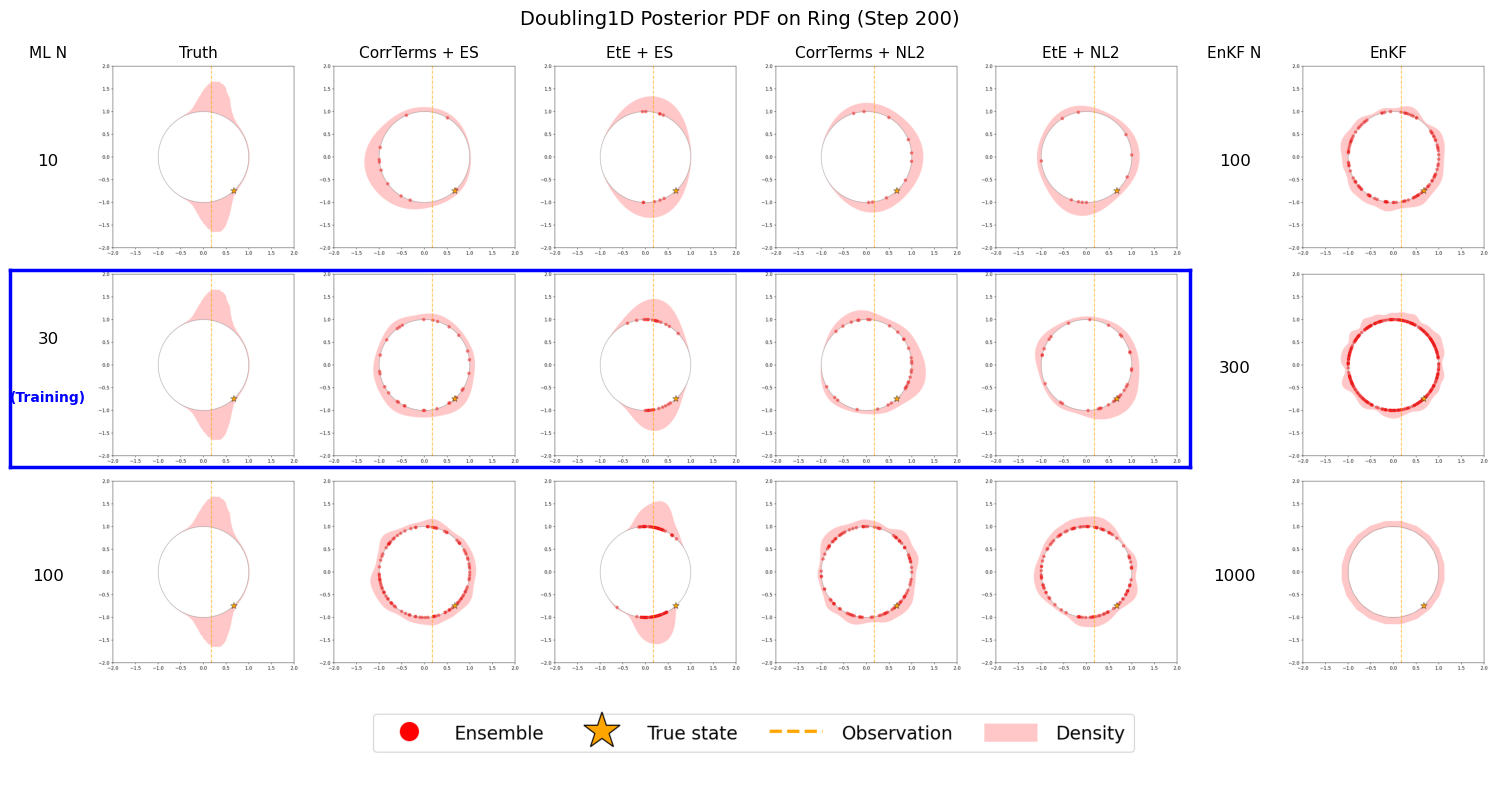

In [3]:
from pathlib import Path
import matplotlib.pyplot as plt

base_dir = Path('save/doubling1d_results')
enkf_dir = Path('save/benchmark_doubling1d_0.2_EnKF')
legend_path = Path('save/benchmark_doubling1d_0.2_EnKF/post_density_legend.png')

methods = [
    ('CorrTerms + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_CorrTermsNone_cos2pi'),
    ('EtE + ES', '2026-02-12_19-24doubling1d_0.2_30_60_8192_es_joint_EtE-LResNone_cos2pi'),
    ('CorrTerms + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_CorrTermsNone_cos2pi'),
    ('EtE + NL2', '2026-02-12_19-24doubling1d_0.2_30_60_8192_nl2_joint_EtE-LResNone_cos2pi'),
]

steps = [100, 150, 200]
ml_ensemble_sizes = [10, 30, 100]
enkf_ensemble_sizes = [100, 300, 1000]
seed = 0

# Legend crop parameters (ratios from 0.0 to 1.0).
legend_crop = {
    'left': 0.1,
    'right': 0.1,
    'top': 0.2,
    'bottom': 0.2,
}
legend_height_ratio = 0.5

if len(ml_ensemble_sizes) != len(enkf_ensemble_sizes):
    raise ValueError('ML and EnKF ensemble-size lists must have the same length.')

if not legend_path.exists():
    raise FileNotFoundError(f'Missing legend image: {legend_path}')


def crop_image(image, crop):
    """
    Crops an image based on provided ratios.
    Input: image array, crop dict with float ratios (0.0 to 1.0)
    Output: cropped image array
    """
    h, w = image.shape[:2]
    
    left = int(w * crop.get('left', 0.0))
    right = int(w * crop.get('right', 0.0))
    top = int(h * crop.get('top', 0.0))
    bottom = int(h * crop.get('bottom', 0.0))

    if left + right >= w:
        raise ValueError(f'Legend crop left+right ratio exceeds 1.0.')
    if top + bottom >= h:
        raise ValueError(f'Legend crop top+bottom ratio exceeds 1.0.')

    x_end = w - right if right > 0 else w
    y_end = h - bottom if bottom > 0 else h
    return image[top:y_end, left:x_end]


legend_img = crop_image(plt.imread(legend_path), legend_crop)

for step in steps:
    timestep = step - 1
    truth_post_path = Path(
        f'save/doubling1d_pf_vis/sigma_y0.2_batch64_len200_pfN1000000_timestep{timestep}_42_g0_POST_0_ring_pdf_on_ring_nohist.png'
    )

    if not truth_post_path.exists():
        raise FileNotFoundError(f'Missing truth image for step {step}: {truth_post_path}')

    nrows = len(ml_ensemble_sizes)
    ncols = 1 + 1 + len(methods) + 1 + 1
    width_ratios = [0.35, 1, 1, 1, 1, 1, 0.38, 1]

    fig = plt.figure(figsize=(15.2, 8.1))
    gs = fig.add_gridspec(
        nrows=nrows + 1,
        ncols=ncols,
        width_ratios=width_ratios,
        height_ratios=[1] * nrows + [legend_height_ratio],
    )

    axes = [[fig.add_subplot(gs[r, c]) for c in range(ncols)] for r in range(nrows)]

    column_titles = ['ML N', 'Truth'] + [m[0] for m in methods] + ['EnKF N', 'EnKF']
    for col, title in enumerate(column_titles):
        axes[0][col].set_title(title, fontsize=11, pad=3)

    missing = []
    truth_img = plt.imread(truth_post_path)

    for row, (ml_n, enkf_n) in enumerate(zip(ml_ensemble_sizes, enkf_ensemble_sizes)):
        ax_ml_n = axes[row][0]
        ax_ml_n.axis('off')
        
        # Add blue bounding box and label for N=30 (excluding EnKF columns)
        if ml_n == 30:
            ax_ml_n.text(0.5, 0.65, str(ml_n), ha='center', va='center', fontsize=12)
            ax_ml_n.text(0.5, 0.35, '(Training)', ha='center', va='center', fontsize=10, color='blue', weight='bold')
            
            # Create a transparent overlay axis spanning columns 0 to 5 (ML columns)
            box_ax = fig.add_subplot(gs[row, 0:6], zorder=10)
            box_ax.set_facecolor('none')
            box_ax.set_xticks([])
            box_ax.set_yticks([])
            for spine in box_ax.spines.values():
                spine.set_edgecolor('blue')
                spine.set_linewidth(2.5)
        else:
            ax_ml_n.text(0.5, 0.5, str(ml_n), ha='center', va='center', fontsize=12)

        axes[row][1].imshow(truth_img)
        axes[row][1].axis('off')

        for i, (_, method_folder) in enumerate(methods):
            col = 2 + i
            ax = axes[row][col]
            image_path = base_dir / method_folder / f'test_{ml_n}_{seed}_g0_slice_step{step}_0_ring_pdf_on_ring_nohist.png'

            if not image_path.exists():
                missing.append(str(image_path))
                ax.axis('off')
                ax.text(0.5, 0.5, 'Missing', ha='center', va='center', fontsize=10)
                continue

            ax.imshow(plt.imread(image_path))
            ax.axis('off')

        ax_enkf_n = axes[row][2 + len(methods)]
        ax_enkf_n.axis('off')
        ax_enkf_n.text(0.5, 0.5, str(enkf_n), ha='center', va='center', fontsize=12)

        ax_enkf = axes[row][3 + len(methods)]
        enkf_path = enkf_dir / f'test_{enkf_n}_0_classic_g0_slice_step{step}_0_ring_pdf_on_ring_nohist.png'

        if not enkf_path.exists():
            missing.append(str(enkf_path))
            ax_enkf.axis('off')
            ax_enkf.text(0.5, 0.5, 'Missing', ha='center', va='center', fontsize=10)
        else:
            ax_enkf.imshow(plt.imread(enkf_path))
            ax_enkf.axis('off')

    if missing:
        raise FileNotFoundError(
            f'Some expected images were not found for step {step}:\n' + '\n'.join(missing)
        )

    legend_ax = fig.add_subplot(gs[nrows, :])
    legend_ax.imshow(legend_img, aspect='equal')
    legend_ax.axis('off')

    fig.suptitle(f'Doubling1D Posterior PDF on Ring (Step {step})', fontsize=14, y=0.985)
    fig.subplots_adjust(left=0.02, right=0.998, top=0.92, bottom=0.03, wspace=0.02, hspace=0.06)

    output_path = Path(f'save/doubling1d_results/doubling1d_results_grid_step{step}_with_enkf_and_legend.png')
    fig.savefig(output_path, dpi=260, bbox_inches='tight', pad_inches=0.02)
    print(f'Saved grid image to: {output_path}')
    plt.show()